In [1]:
import quairkit as qkit
from quairkit.database import *
from quairkit.qinfo import *
from quairkit.operator import *
import numpy as np
import time
import numpy as np
import torch
from matplotlib import pyplot as plt
from quairkit import Circuit
from quairkit.loss import *
import torch.nn as nn
import torch.optim as optim

In [2]:
def circle_data_point_generator(Ntrain, Ntest, boundary_gap, seed_data):
    """
    :param Ntrain: number of training samples
    :param Ntest: number of test samples
    :param boundary_gap: value in (0, 0.5), means the gap between two labels
    :param seed_data: random seed
    :return: 'Ntrain' samples for training and
             'Ntest' samples for testing
    """
    # Generate "Ntrain + Ntest" pairs of data, x for 2-dim data points, y for labels.
    # The first "Ntrain" pairs are used as training set, the last "Ntest" pairs are used as testing set
    train_x, train_y = [], []
    num_samples, seed_para = 0, 0
    while num_samples < Ntrain + Ntest:
        np.random.seed((seed_data + 10) * 1000 + seed_para + num_samples)
        data_point = np.random.rand(2) * 2 - 1  # 2-dim vector in range [-1, 1]

        # If the modulus of the data point is less than (0.7 - gap), mark it as 0
        if np.linalg.norm(data_point) < 0.7-boundary_gap / 2:
            train_x.append(data_point)
            train_y.append(0.)
            num_samples += 1

        # If the modulus of the data point is greater than (0.7 + gap), mark it as 1
        elif np.linalg.norm(data_point) > 0.7 + boundary_gap / 2:
            train_x.append(data_point)
            train_y.append(1.)
            num_samples += 1
        else:
            seed_para += 1

    train_x = np.array(train_x).astype("float64")
    train_y = np.array([train_y]).astype("float64").T

    print("The dimensions of the training set x {} and y {}".format(np.shape(train_x[0:Ntrain]), np.shape(train_y[0:Ntrain])))
    print("The dimensions of the test set x {} and y {}".format(np.shape(train_x[Ntrain:]), np.shape(train_y[Ntrain:])), "\n")

    return train_x[0:Ntrain], train_y[0:Ntrain], train_x[Ntrain:], train_y[Ntrain:]

In [3]:
def data_point_plot(data, label):
    """
    :param data: shape [M, 2], means M 2-D data points
    :param label: value 0 or 1
    :return: plot these data points
    """
    color1 = np.array([209,83,84])/256
    color2 = np.array([80,148,213])/256
    color3 = np.array([229,153,129])/256
    color4 = np.array([171,216,229])/256
    color5 = np.array([94,90,158])/256
    color6 = np.array([101,154,111])/256

    dim_samples, dim_useless = np.shape(data)
    # plt.figure(1)
    fig = plt.figure(figsize=[5,4])
    for i in range(dim_samples):
        if label[i] == 0:
            plt.plot(data[i][0], data[i][1], color=color1, marker="o")
        elif label[i] == 1:
            plt.plot(data[i][0], data[i][1], color=color2, marker="o")

    plt.yticks([-1,-0.5,0,0.5,1],fontproperties = 'Times New Roman', size = 16)
    plt.xticks([-1,-0.5,0,0.5,1],fontproperties = 'Times New Roman', size = 16)
    plt.savefig('Training Data.png', dpi=400,bbox_inches='tight')
    plt.show()
    

In [4]:
# Construct quantum circuit for data encoding
def encoding_circuit(data, n_qubits):
    cir = Circuit(n_qubits)
    for i in range(n_qubits):
        param = data[0] if i % 2 == 0 else data[1]
        cir.ry(qubits_idx=i, param=np.arcsin(param))
        cir.rz(qubits_idx=i, param=np.arccos(param**2))
    return cir


# Encode the data points to quantum states
def datapoints_transform_to_state(data, n_qubits):
    """
    :param data: shape [BATCHSIZE, 2]
    :param n_qubits: the number of qubits to which
    the data transformed
    :return: shape [BATCHSIZE, 1, 2 ^ n_qubits]
    """

    batchsize, _ = data.shape
    res = []
    init_state = zero_state(n_qubits)
    for i in range(batchsize):
        cir = encoding_circuit(data[i], n_qubits)
        out_state = cir(init_state)
        res.append(out_state)
        # res.append(out_state.numpy().reshape(1, -1))
    # res = np.array(res, dtype=np.complex64)
    return res

In [5]:
def pauli_z_observable(n_qubits):
    Z = np.array([[1, 0], [0, -1]])
    I = np.eye(2)
    observable = Z
    for _ in range(n_qubits - 1):
        observable = np.kron(observable, I)

    return observable

## 2 qubits ansatz
def complex_entangled_layer_by_hand(n_qubits, depth):
    cir = Circuit(n_qubits)
    
    for d in range(depth):
        cir.rx([0, 1])
        cir.depolarizing(0.02, [0, 1])
        cir.ry([0, 1])
        cir.depolarizing(0.02, [0, 1])
        
        cir.cz([0,1])
        cir.generalized_depolarizing(0.05, [0, 1])

    return cir


In [6]:
def loss_fcn(Ntrain, Ntest, num_qubits, cir1, cir2, budget):
    c1 = (budget-1)/2 + 1
    c2 = (budget-1)/2
    Ob = pauli_z_observable(num_qubits)
    Ob = torch.tensor(Ob, dtype=torch.complex64)
    
    loss = 0
    is_correct_train = 0
    for i in range(Ntrain):
        output1 = cir1(encoded_train_states_list[i])
        output2 = cir2(encoded_train_states_list[i])
        predict = (1 + c1*trace(output1.density_matrix @ Ob).real - c2*trace(output2.density_matrix @ Ob).real)/2
        loss += (predict - torch.tensor(train_y[i][0]))**2
        if (predict.abs() - torch.tensor(train_y[i][0])).abs() <= 0.5:
            is_correct_train += 1
    train_acc = is_correct_train/Ntrain

    is_correct_test = 0
    for j in range(Ntest):
        output1 = cir1(encoded_test_states_list[j])
        output2 = cir2(encoded_test_states_list[j])
        predict = (1 + c1*trace(output1.density_matrix @ Ob).real - c2*trace(output2.density_matrix @ Ob).real)/2
        if (predict.abs() - torch.tensor(test_y[j][0])).abs() <= 0.5:
            is_correct_test += 1
    test_acc = is_correct_test/Ntest

    return  loss/Ntrain, train_acc, test_acc
    

In [7]:
def train_model(Ntrain, Ntest, num_itr, LR, num_qubits, depth, budget):

    cir1 = complex_entangled_layer_by_hand(num_qubits, depth)
    cir2 = complex_entangled_layer_by_hand(num_qubits, depth)

    loss_list, time_list, train_acc_list, test_acc_list = [], [], [], []

    opt = torch.optim.Adam(lr=LR, params=list(cir1.parameters()) + list(cir2.parameters())) # cir is a Circuit type
    # opt = torch.optim.SGD(lr=LR, params=list(cir1.parameters()) + list(cir2.parameters())) # cir is a Circuit type
    # opt = torch.optim.AdamW(lr=LR, params=list(cir1.parameters()) + list(cir2.parameters())) # cir is a Circuit type
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5) # activate scheduler

    for itr in range(num_itr):
        start_time = time.time()
        opt.zero_grad()

        loss,train_acc,test_acc = loss_fcn(Ntrain, Ntest, num_qubits, cir1, cir2, budget) # compute loss

        loss.backward()
        opt.step()

        loss = loss.item()
        scheduler.step(loss) # activate scheduler

        loss_list.append(loss)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)


        time_list.append(time.time() - start_time)

        if itr % (num_itr // 10) == 0 or itr == num_itr - 1:
            print(f"iter: {str(itr).zfill(len(str(num_itr)))}, " +
                f"loss: {loss:.8f}, " + f"train_acc: {train_acc:.8f}, "+ f"test_acc: {test_acc:.8f}, " +
                f"lr: {scheduler.get_last_lr()[0]:.2E}, avg_time: {np.mean(time_list):.4f}s")
            time_list = []

    return train_acc, test_acc
    # display_results(loss_list, lambda_0, cir1)
    # return ave_exp, ave_state
    

The dimensions of the training set x (200, 2) and y (200, 1)
The dimensions of the test set x (100, 2) and y (100, 1) 

Visualization of 150 data points in the training set: 


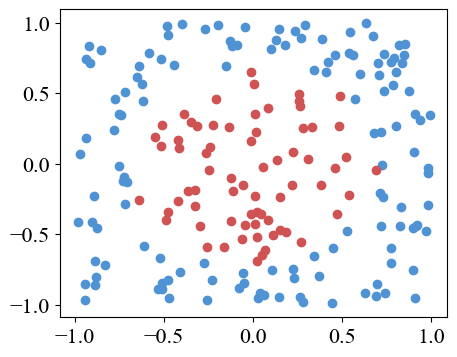

Visualization of Ntest data points in the test set: 


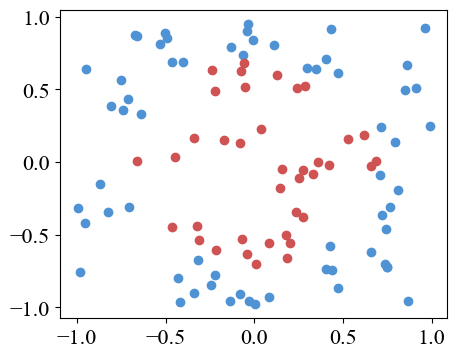

In [8]:
Ntrain = 200
Ntest = 100
NUM_ITR = 150  # Set the number of optimization iterations
num_qubits = 2 # 4
LR = 0.2     # Set the learning rate
depth = 2
# budget = 1.5

# Generate data set
train_x, train_y, test_x, test_y = circle_data_point_generator(Ntrain, Ntest, boundary_gap=0, seed_data=np.random.randint(1,500))

encoded_train_states_list = datapoints_transform_to_state(train_x, num_qubits)
encoded_test_states_list = datapoints_transform_to_state(test_x, num_qubits)

# Visualization
print("Visualization of 150 data points in the training set: ")
data_point_plot(train_x, train_y)
print("Visualization of Ntest data points in the test set: ")
data_point_plot(test_x, test_y)

In [10]:
train_acc_list = []
test_acc_list = []
for budget in np.linspace(1,3,5):
    print('budget = ', budget)
    train_acc, test_acc = train_model(Ntrain, Ntest, NUM_ITR, LR, num_qubits, depth, budget)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

print(train_acc_list)
print(test_acc_list)

budget =  1.0
iter: 000, loss: 0.25919666, train_acc: 0.39000000, test_acc: 0.42000000, lr: 2.00E-01, avg_time: 2.0848s
iter: 015, loss: 0.22880679, train_acc: 0.65500000, test_acc: 0.57000000, lr: 2.00E-01, avg_time: 3.2464s
iter: 030, loss: 0.22433630, train_acc: 0.65500000, test_acc: 0.66000000, lr: 2.00E-01, avg_time: 3.2553s
iter: 045, loss: 0.22319040, train_acc: 0.63000000, test_acc: 0.66000000, lr: 1.00E-01, avg_time: 2.1936s
iter: 060, loss: 0.22297772, train_acc: 0.65000000, test_acc: 0.65000000, lr: 1.00E-01, avg_time: 2.1746s
iter: 075, loss: 0.22295089, train_acc: 0.64000000, test_acc: 0.64000000, lr: 5.00E-02, avg_time: 2.1935s
iter: 090, loss: 0.22294843, train_acc: 0.64500000, test_acc: 0.65000000, lr: 2.50E-02, avg_time: 2.1843s
iter: 105, loss: 0.22294774, train_acc: 0.65000000, test_acc: 0.65000000, lr: 1.25E-02, avg_time: 1.8896s
iter: 120, loss: 0.22294756, train_acc: 0.65000000, test_acc: 0.65000000, lr: 3.13E-03, avg_time: 1.8927s
iter: 135, loss: 0.22294754, tra

In [ ]:
train_1 = [0.62, 0.635, 0.68, 0.67, 0.68]
test_1 = [0.46, 0.65, 0.61, 0.66, 0.69]

train_2 = [0.635, 0.66, 0.68, 0.74, 0.74]
test_2 =  [0.6, 0.65, 0.66, 0.63, 0.68]

train_3 = [0.64, 0.625, 0.72, 0.755, 0.76]
test_3 = [0.62, 0.64, 0.64, 0.67, 0.68]

train_4 = [0.675, 0.725, 0.765, 0.79, 0.785]
test_4 = [0.63, 0.66, 0.73, 0.78, 0.79]

train_5 = [0.635, 0.67, 0.655, 0.665, 0.745]
test_5 = [0.63, 0.64, 0.7, 0.71, 0.81]

train_6 = [0.615, 0.655, 0.655, 0.685, 0.74]
test_6 = [0.54, 0.56, 0.65, 0.61, 0.67]

train_7 = [0.635, 0.785, 0.795, 0.81, 0.815]
test_7 = [0.6, 0.78, 0.8, 0.8, 0.82]

train_8 = [0.67, 0.62, 0.725, 0.735, 0.745]
test_8 = [0.71, 0.61, 0.76, 0.76, 0.77]

train_9 = [0.635, 0.665, 0.68, 0.715, 0.735]
test_9 = [0.61, 0.64, 0.7, 0.71, 0.69]

train_10 = [0.69, 0.69, 0.755, 0.76, 0.76]
test_10 = [0.69, 0.67, 0.76, 0.74, 0.75]

train_data = np.array([train_1, train_2, train_3, train_4, train_5, train_6, train_7, train_8, train_9, train_10])
test_data = np.array([test_1, test_2, test_3, test_4, test_5, test_6, test_7, test_8, test_9, test_10])


train_mean_list = np.mean(train_data, axis=0).tolist()
train_std_list = np.std(train_data, axis=0).tolist()

test_mean_list = np.mean(test_data, axis=0).tolist()
test_std_list = np.std(test_data, axis=0).tolist()

print("train_ave:", train_mean_list)
print("train_std:", train_std_list)

print("test_ave:", test_mean_list)
print("test_std:", test_std_list)

train_ave: [0.6449999999999999, 0.673, 0.711, 0.7325, 0.7505000000000001]
train_std: [0.023452078799117145, 0.04760252094164762, 0.04619523784980439, 0.04654299087940094, 0.03320015060206804]
test_ave: [0.609, 0.65, 0.701, 0.7070000000000001, 0.735]
test_std: [0.06699999999999998, 0.0523450093132096, 0.05821511831131154, 0.06067124524847006, 0.056258332716140814]


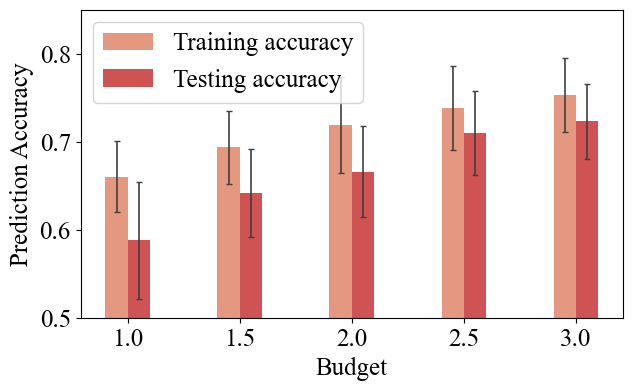

In [ ]:
color1 = np.array([209,83,84])/256
color2 = np.array([80,148,213])/256
color3 = np.array([229,153,129])/256
color4 = np.array([171,216,229])/256
color5 = np.array([94,90,158])/256
color6 = np.array([101,154,111])/256

fig = plt.figure(figsize=[7, 4])
width = 0.1

x = np.array([1, 1.5, 2, 2.5, 3])
train_ave = [0.66, 0.6935000000000001, 0.7190000000000001, 0.7379999999999999, 0.7530000000000001]
train_std = [0.04037325847637269, 0.04195533339159634, 0.05439669107583658, 0.047916594202843735, 0.04226109321823089]
test_ave = [0.5880000000000001, 0.642, 0.666, 0.71, 0.723]
test_std = [0.06630233781700309, 0.04975942121849891, 0.05161395160225573, 0.04795831523312719, 0.042438190347845885]


# plt.bar(x - width/2, train_ave, width, color=color3, label='Training accuracy',
#         yerr=train_std, capsize=4,
#         error_kw={'ecolor': 'black', 'elinewidth': 1.2})
# plt.bar(x + width/2, test_ave, width, color=color1, label='Testing accuracy',
#         yerr=test_std, capsize=4,
#         error_kw={'ecolor': 'black', 'elinewidth': 1.2})

plt.bar(x - width/2, train_ave, width, color=color3, label='Training accuracy',
        yerr=train_std, capsize=2.5,
        error_kw={'ecolor': '#404040', 'elinewidth': 1.2})
plt.bar(x + width/2, test_ave, width, color=color1, label='Testing accuracy',
        yerr=test_std, capsize=2.5,
        error_kw={'ecolor': '#404040', 'elinewidth': 1.2})

plt.xlabel('Budget', fontdict={'family': 'Times New Roman', 'size': 18})
plt.ylabel('Prediction Accuracy', fontdict={'family': 'Times New Roman', 'size': 18})
plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9], fontproperties='Times New Roman', size=18)
plt.xticks(x, fontproperties='Times New Roman', size=18)
plt.legend(prop={'family': 'Times New Roman', 'size': 18})
plt.ylim([0.5, 0.85])
plt.savefig('VQC.png', dpi=400, bbox_inches='tight')
plt.show()